# PDS classification with the PDSclassifier package

- [Paper](https://www.nature.com/articles/s41588-024-01654-5)
- [GitHub](https://github.com/sidmall/PDSclassifier?tab=readme-ov-file)

>PDSclassifier R package provides a pathway-based molecular classification system for colorectal cancer (CRC), which can be applied to gene expression profiles to stratify into three Pathway-Derived Subtype (PDS): PDS1, PDS2 and PDS3, with distinct molecular biology.

>We defined three pathway-derived subtypes (PDS) in CRC: 
>- PDS1 tumors, which are canonical/LGR5+ stem-rich, highly proliferative and display good prognosis;
>- PDS2 tumors, which are regenerative/ANXA1+ stem-rich, with elevated stromal and immune tumor microenvironmental lineages;
>- PDS3 tumors, which represent a previously overlooked slow-cycling subset of tumors within CMS2 with reduced stem populations and increased differentiated lineages, particularly enterocytes and enteroendocrine cells, yet display the worst prognosis in locally advanced disease. These PDS3 phenotypic traits are evident across numerous bulk and single-cell datasets, and demark a series of subtle biological states that are currently under-represented in pre-clinical models and are not identified using existing subtyping classifiers.

The CMS to PDS associations that they found in different sample sets, in figure 2c and extended data figure 1d:

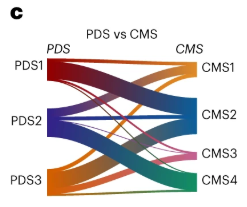
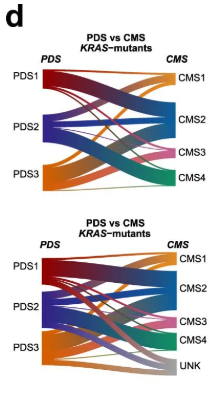

In [ ]:
getwd() |> gsub('results/.*$', '', x=_) |> setwd()

if (!"PDSclassifier" %in% installed.packages()) {devtools::install_github('sidmall/PDSclassifier')}
if (!"escape" %in% installed.packages()) {BiocManager::install("escape")}

library(PDSclassifier)
library(tidyverse)
load("/data/cephfs-1/home/users/cemo10_c/work/scRNA/scRNA_preprocessing_pipeline/resources/sysdata.rda")

In [11]:
input_file = "../../results/merged_metacells/chosen_branch/srt_subset.rds"
output_csv = "PDS_classifier.csv"
clusters_file = "../../results/merged_metacells/chosen_branch/clusters_leiden_monocle3.csv"

In [13]:
suppressPackageStartupMessages({library(Seurat)})
srt = readRDS(input_file)
names(srt@reductions)[1:4] = c('diffmap', 'pca', 'tsne', 'umap')
#names(srt@reductions) = c('diffmap', 'pca', 'tsne', 'umap')

# set colors for PDS types
pds_col = c("#f8776e", "#7cae00", "#c77dff", "grey")

srt

An object of class Seurat 
11449 features across 692 samples within 1 assay 
Active assay: RNA (11449 features, 0 variable features)
 2 layers present: counts, data
 4 dimensional reductions calculated: diffmap, pca, tsne, umap

In [14]:
Features(srt) |> head()

# Check if gene names start with "ENSG"
if (all(startsWith(rownames(srt), "ENSG"))) {
	ensembl2_symbol <- read.delim("../../resources/ensembl2genes_cellranger.tsv", header = FALSE, sep = "\t", stringsAsFactors = FALSE)
	ensembl_map <- setNames(ensembl2_symbol$V2, ensembl2_symbol$V1)
	hgnc_symbol <- ensembl_map[rownames(srt)]
	srt@assays$RNA@meta.features$hgnc_symbol <- hgnc_symbol
	srt@assays$RNA@meta.features$ensembl_id <- rownames(srt)
	scop::RenameFeatures(srt, newnames = hgnc_symbol)
}

rownames(srt) |> head()

[1] "NOC2L"   "KLHL17"  "PLEKHN1" "HES4"    "ISG15"   "AGRN"

[1] "NOC2L"   "KLHL17"  "PLEKHN1" "HES4"    "ISG15"   "AGRN"

The function does not work with our data because not all predictors from their SVM model could be computed, probably because of some missing genes. We can fix that by adding the missing predictors with only zero values so that they do not affect the results.

In [15]:
# fixed function from package
PDSpredict_fixed = function(x, species, threshold = 0.6) {
    ### examine if  '///' string genes are present and any duplicated genes
    if (nrow(x[duplicated(gsub("\\s.*", "", x[, 1])), ]) > 0){
    x <- highMeanGene(x)
    } else {
    rownames(x) <- x[,1]
    x <- x[,-1]
    x <- as.matrix(x)
    }

    ### Get the C2 (BIOCARTA, KEGG, PID, REACTOME) gene set, saved from MSigDB
    if (species == "mouse") {

    c2.geneset <- mouse.c2.geneset.list

    } else {

    c2.geneset <- human.c2.geneset.list
    }

    ### default threshold = 0.6
    if (threshold < 0 | threshold > 1) {
    stop('Set threshold between 0 and 1')
    } else {
    threshold <- threshold}

    ### Generate single sample GSEA scores (ssGSEA)
    message('Calculating ssGSEA scores...')
    ### set seed
    if (as.Date(paste0(R.version$year,'-',R.version$month,'-',R.version$day)) >= as.Date('2019-04-26'))
    {suppressWarnings(set.seed(123, sample.kind = 'Rounding'))} else{set.seed(123)}


    ### package version change of GSVA
    if(utils::packageVersion("GSVA") <= "1.48.3" ) {

        ### ssGSEA
        y <- suppressWarnings(GSVA::gsva(x, c2.geneset, max.sz = Inf, ## min.size default as it may lead to no gene set scores
                                            verbose = F, method = "ssgsea", parallel.sz = 4,
                                            ssgsea.norm = F))

    } else {

        ### ssGSEA -- update
        ssgsea_par <- GSVA::ssgseaParam(x, c2.geneset,
                                        maxSize = Inf, ## min.size default as it may lead to no gene set scores
                                        normalize = F)
        y <- suppressWarnings(GSVA::gsva(ssgsea_par, verbose = F, BPPARAM = BiocParallel::SnowParam(workers = 4)))

    }

    ### Apply scaling with fixed value from training set.
    minmax_diff <- 20928.93
    y.1 <- as.data.frame(sapply(as.data.frame(y), function(s) {s/(minmax_diff)}))
    rownames(y.1) <- rownames(y)
    y.1 <- as.data.frame(y.1)
    y.1[['gs_name']] <- rownames(y.1)
    y.1 <- dplyr::select(y.1, c('gs_name', dplyr::everything()))
    y.1$gs_name <- gsub('\\.', ':', y.1$gs_name)
    cat("ssGSEA Complete!\n")


    ### train data
    train.data.1 <- trainData[,-c(1:2)]
    rownames(train.data.1) <- trainData[,1]
    train.data.1 <- as.data.frame(t(train.data.1))
    train.data.1[['gs_name']] <- rownames(train.data.1)
    train.data.1 <- dplyr::select(train.data.1, c('gs_name', dplyr::everything()))

    ### merge traindata with new data
    merge.1 <- merge(train.data.1, y.1, by = "gs_name")
    rownames(merge.1) <- merge.1[["gs_name"]]
    merge.1 <- merge.1[,-1]
    nrow(train.data.1) == nrow(merge.1)

    ### check for batch effect
    message('Batch Correction (with training set as reference batch)...')
    combi <- suppressMessages(sva::ComBat(dat = as.matrix(merge.1),
                                        batch = c(rep(1,ncol(train.data.1[,-1])),
                                                    rep(2,ncol(y.1[,-1]))),
                                        mod = NULL,
                                        ref.batch = 1,
                                        par.prior = T,
                                        prior.plots = F))

    cat("Batch Correction Complete!\n")

    ############# It fails here. There are missing predictors
    
    missing_predictors <- setdiff(rownames(train.data.1), rownames(combi))

    # Add rows for the missing predictors, setting their values to 0
    for (predictor in missing_predictors) {
        new_row <- matrix(0, nrow = 1, ncol = ncol(combi))
        rownames(new_row) <- predictor
        combi <- rbind(combi, new_row)
    }

    # Ensure the predictors are in the correct order
    combi <- combi[rownames(train.data.1), , drop = FALSE]
    stopifnot(nrow(combi) == nrow(train.data.1))

    combi.train.data <- combi[, c(1:ncol(train.data.1[,-1]))]
    new.data.mtx <- combi[,c((ncol(train.data.1[,-1])+1):(ncol(train.data.1[,-1])+ncol(y.1[,-1])))]


    message('Applying the svmRBF classification model...')

    ### Set the seed for reproducibility
    if (as.Date(paste0(R.version$year,'-',R.version$month,'-',R.version$day)) >= as.Date('2019-04-26'))
    {suppressWarnings(set.seed(40218336, sample.kind = 'Rounding'))} else{set.seed(40218336)}

    svm.predict <- stats::predict(svm.model, t(new.data.mtx))

    ### Final decision on prediction calls
    PDS.predict <- stats::predict(svm.model, t(new.data.mtx), type = "prob")
    rownames(PDS.predict) <- rownames(t(new.data.mtx))
    PDS.predict[['Sample_ID']] <- rownames(PDS.predict)
    PDS.predict <- dplyr::select(PDS.predict, c('Sample_ID', dplyr::everything()))
    PDS.predict <- data.frame(PDS.predict, prediction = svm.predict)

    PDS.predict[["PDS_call"]] <- ifelse(PDS.predict[["PDS1"]] > threshold, "PDS1",
                                        ifelse(PDS.predict[["PDS2"]] > threshold, "PDS2",
                                                ifelse(PDS.predict[["PDS3"]] > threshold, "PDS3", "Mixed")))

    cat("Classification Complete!\n")
    if(any(rownames(utils::installed.packages()) %in% "beepr"))
        beepr::beep(sound = 4)


    PDS.predict <- dplyr::mutate(PDS.predict, PDS_call = factor(PDS.predict$PDS_call,
                                                                levels = c('PDS1', 'PDS2',
                                                                            'PDS3', 'Mixed')))

    return(PDS.predict)
}

## Pseudo-bulk per cluster

First, I will apply the PDSclassifier to the pseudo-bulk data per cluster. We expect the clusters to be distinct from each other, possibly with different PDS subtypes.

In [16]:
clusters = read.csv(clusters_file) |> dplyr::rename(cluster = !!2) |> tibble::column_to_rownames("X")
# stopifnot(all(rownames(srt@meta.data) == rownames(clusters))) # check if same cells
srt$clusters = clusters

In [17]:
# Here we use AverageExpression instead of AggregateExpression to create pseudobulk data because we want to use normalized data
aex_per_cluster = AverageExpression(srt, layer = "data", assays = "RNA", 
                                    return.seurat = F, group.by = "clusters")
aex_per_cluster = as.data.frame(aex_per_cluster$RNA)

# rownames to first column
aex_per_cluster$Gene.Symbol = rownames(aex_per_cluster)
aex_per_cluster = aex_per_cluster[,c(ncol(aex_per_cluster), 1:(ncol(aex_per_cluster)-1))]
rownames(aex_per_cluster) = NULL
head(aex_per_cluster)

PDS.predict_per_cluster = PDSpredict_fixed(x = aex_per_cluster, species = 'human', threshold = 0.6)
PDS.predict_per_cluster

,Gene.Symbol,g1,g2,g3,g4,g5,g6
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,NOC2L,0.72952397,0.43365108,0.38364113,1.15127476,0.64067424,0.14771587
2,KLHL17,0.03256137,0.02787977,0.03327652,0.00000000,0.04716667,0.00000000
3,PLEKHN1,0.04593997,0.09689906,0.11432978,0.02355199,0.03446103,0.01943650
4,HES4,0.03746836,0.05657744,0.08090712,0.09132207,0.04151599,0.02384131
5,ISG15,0.63954357,0.90898685,0.90369414,0.91497986,1.05285367,1.59460822
6,AGRN,1.70562628,1.76599122,2.00996910,0.39518401,1.38388476,0.89464049


Calculating ssGSEA scores...

! Some gene sets have size one. Consider setting minSize > 1



ssGSEA Complete!


Batch Correction (with training set as reference batch)...



Batch Correction Complete!


Applying the svmRBF classification model...



Classification Complete!


,Sample_ID,PDS1,PDS2,PDS3,prediction,PDS_call
,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
g1,g1,0.873691535,0.06869612,0.05761235,PDS1,PDS1
g2,g2,0.021822609,0.19641558,0.78176181,PDS3,PDS3
g3,g3,0.007221485,0.09238118,0.90039733,PDS3,PDS3
g4,g4,0.857395150,0.12229676,0.02030809,PDS1,PDS1
g5,g5,0.053262171,0.06035047,0.88638736,PDS3,PDS3
g6,g6,0.005815318,0.88106103,0.11312365,PDS2,PDS2


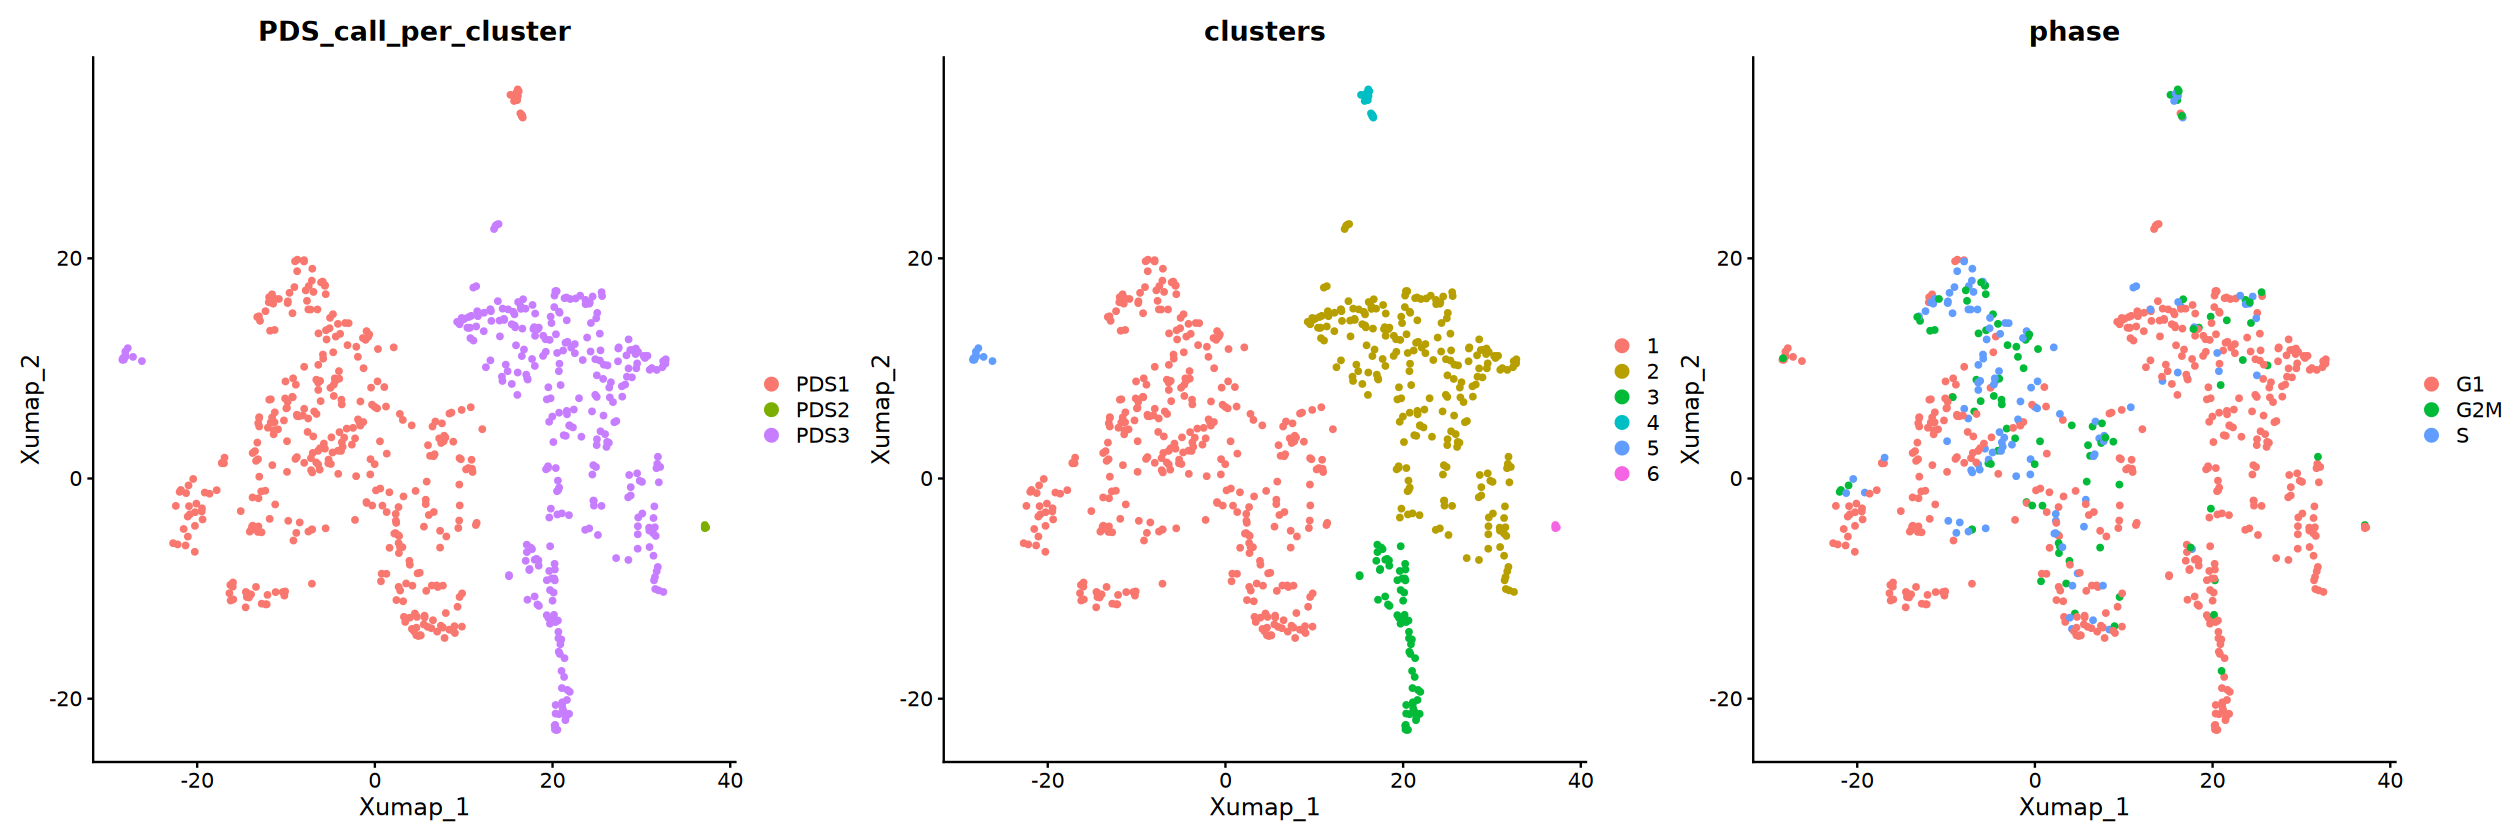

In [18]:
# add to cell annotation and save
srt$PDS_call_per_cluster = PDS.predict_per_cluster$PDS_call[
    match(paste0('g', srt$clusters), PDS.predict_per_cluster$Sample_ID)]
write.csv(srt$PDS_call_per_cluster, output_csv, row.names = T)

options(repr.plot.width = 21, repr.plot.height = 7)
p1 = DimPlot(srt, group.by = "PDS_call_per_cluster", reduction = "umap", 
             cols = pds_col, na.value="lightgrey")
p2 = DimPlot(srt, group.by = "clusters", reduction = "umap")
p3 = DimPlot(srt, group.by = "phase", reduction = "umap")
p1 + p2 + p3

## Pseudo-bulk per sample and cluster

Do the clusters represent clearly different PDS types, or do clusters _transition_ from one type to the other because something else determines the clusters?

In [19]:
aex_per_sample_and_cluster = AverageExpression(srt, layer = "data", assays = "RNA", 
                                               return.seurat = F, group.by = c("sample", "clusters"))
aex_per_sample_and_cluster = as.data.frame(aex_per_sample_and_cluster$RNA)

# rownames to first column
aex_per_sample_and_cluster$Gene.Symbol = rownames(aex_per_sample_and_cluster)
aex_per_sample_and_cluster = aex_per_sample_and_cluster[,c(ncol(aex_per_sample_and_cluster), 1:(ncol(aex_per_sample_and_cluster)-1))]
rownames(aex_per_sample_and_cluster) = NULL
head(aex_per_sample_and_cluster)

,Gene.Symbol,C-1_1,C-1_3,C-1_4,C-2_1,C-2_2,C-2_3,C-2_4,C-2_5,C-3_1,⋯,OnOff-3_2,OnOff-4_1,OnOff-4_2,OnOff-4_3,OnOff-4_6,OnOff-5_1,OnOff-5_2,OnOff-5_4,OnOff-5_5,OnOff-5_6
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,NOC2L,0.76544490,0.51473964,1.5974441,0.73777331,0.57860471,0.39873917,1.2507556,1.4938751,0.73889642,⋯,0.31344314,1.09007649,0.37303454,0.5678454,0.00000000,0.75002007,0.44130844,0.87226859,0.4240985,0.1126177
2,KLHL17,0.02529301,0.03546346,0.0000000,0.03206921,0.02515673,0.03073158,0.0000000,0.0000000,0.03366372,⋯,0.01924359,0.03938860,0.03991687,0.0000000,0.00000000,0.05102056,0.03745468,0.00000000,0.0605855,0.0000000
3,PLEKHN1,0.04009170,0.08740076,0.2282063,0.04786341,0.20125381,0.09645478,0.0000000,0.0000000,0.04638302,⋯,0.08551954,0.05096860,0.11342255,0.0000000,0.07774599,0.04979378,0.11432510,0.00000000,0.0000000,0.0000000
4,HES4,0.01978171,0.00000000,0.0000000,0.04080246,0.00000000,0.04463329,0.1552747,0.0000000,0.04025931,⋯,0.03788089,0.02113218,0.09427664,0.0000000,0.00000000,0.06228368,0.13109549,0.09884353,0.0000000,0.0000000
5,ISG15,0.57371337,0.51253794,0.4564126,0.68487057,0.90564215,1.18703603,1.0135645,0.9959167,0.48842744,⋯,0.83691186,0.25090873,0.81682854,0.4867246,0.85520587,0.36603589,1.08180798,0.09884353,1.1511245,2.2523537
6,AGRN,1.66481333,2.08253280,0.0000000,1.74625817,1.98738139,1.70281665,0.1825801,1.3278890,1.64657500,⋯,1.68808877,1.47968524,2.10123324,1.9468983,1.16618982,1.62696186,1.41233511,1.06995565,1.2117100,0.7883238


In [20]:
PDS.predict_per_sample_and_cluster = PDSpredict_fixed(x = aex_per_sample_and_cluster, species = 'human', threshold = 0.6)
PDS.predict_per_sample_and_cluster |> head()

Calculating ssGSEA scores...

! Some gene sets have size one. Consider setting minSize > 1



ssGSEA Complete!


Batch Correction (with training set as reference batch)...



Batch Correction Complete!


Applying the svmRBF classification model...



Classification Complete!


,Sample_ID,PDS1,PDS2,PDS3,prediction,PDS_call
,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
C-1_1,C-1_1,0.916733331,0.05895346,0.02431321,PDS1,PDS1
C-1_3,C-1_3,0.040437851,0.28750871,0.67205344,PDS3,PDS3
C-1_4,C-1_4,0.527355430,0.37293984,0.09970473,PDS1,Mixed
C-2_1,C-2_1,0.886786439,0.07262759,0.04058597,PDS1,PDS1
C-2_2,C-2_2,0.006357537,0.07973386,0.91390860,PDS3,PDS3
C-2_3,C-2_3,0.002144330,0.06611829,0.93173738,PDS3,PDS3


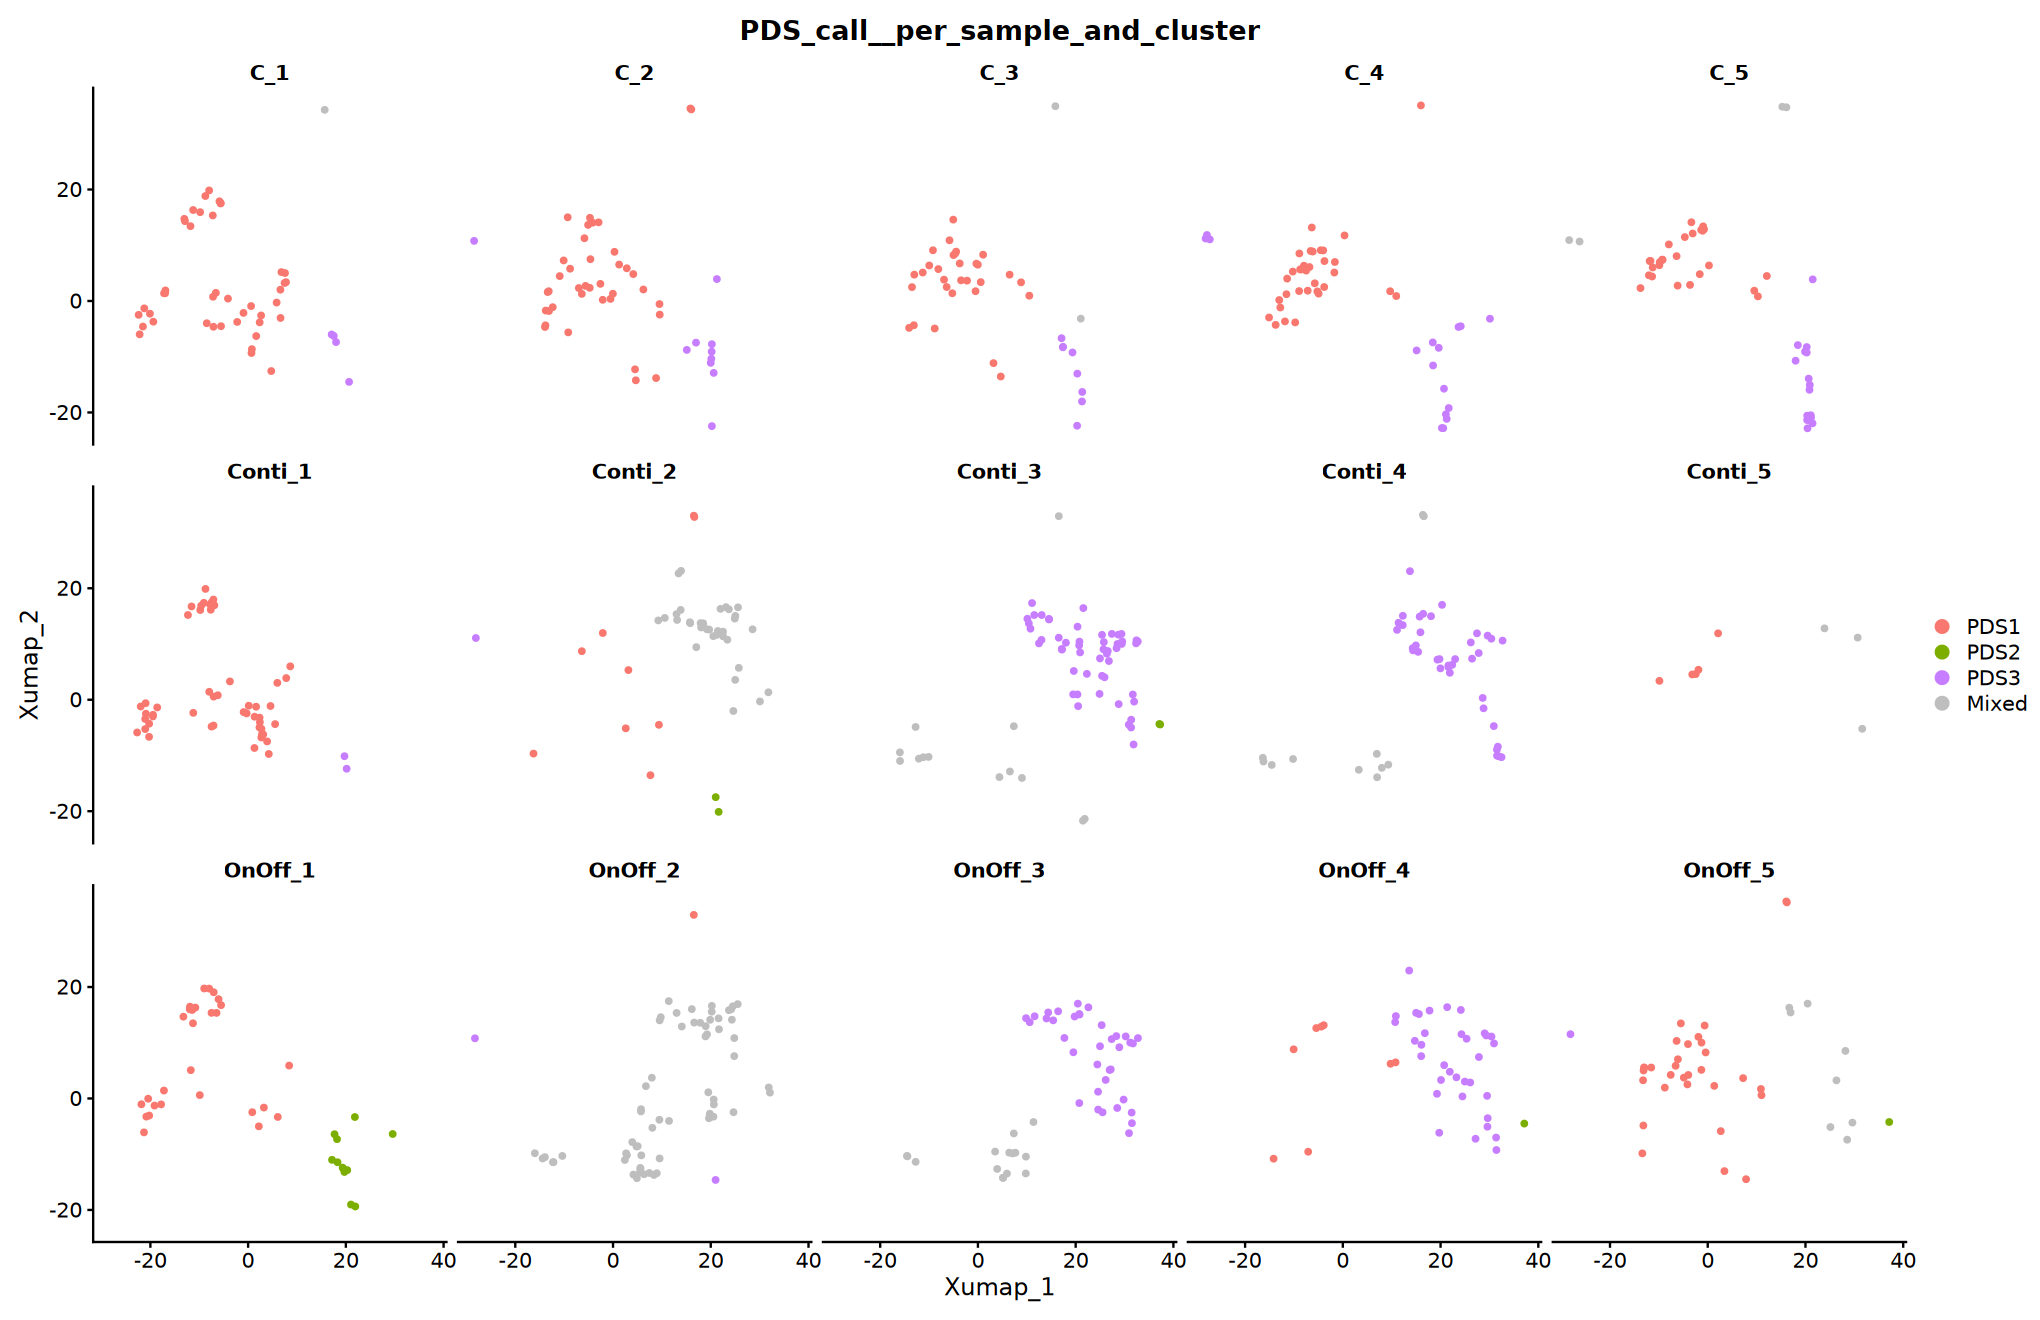

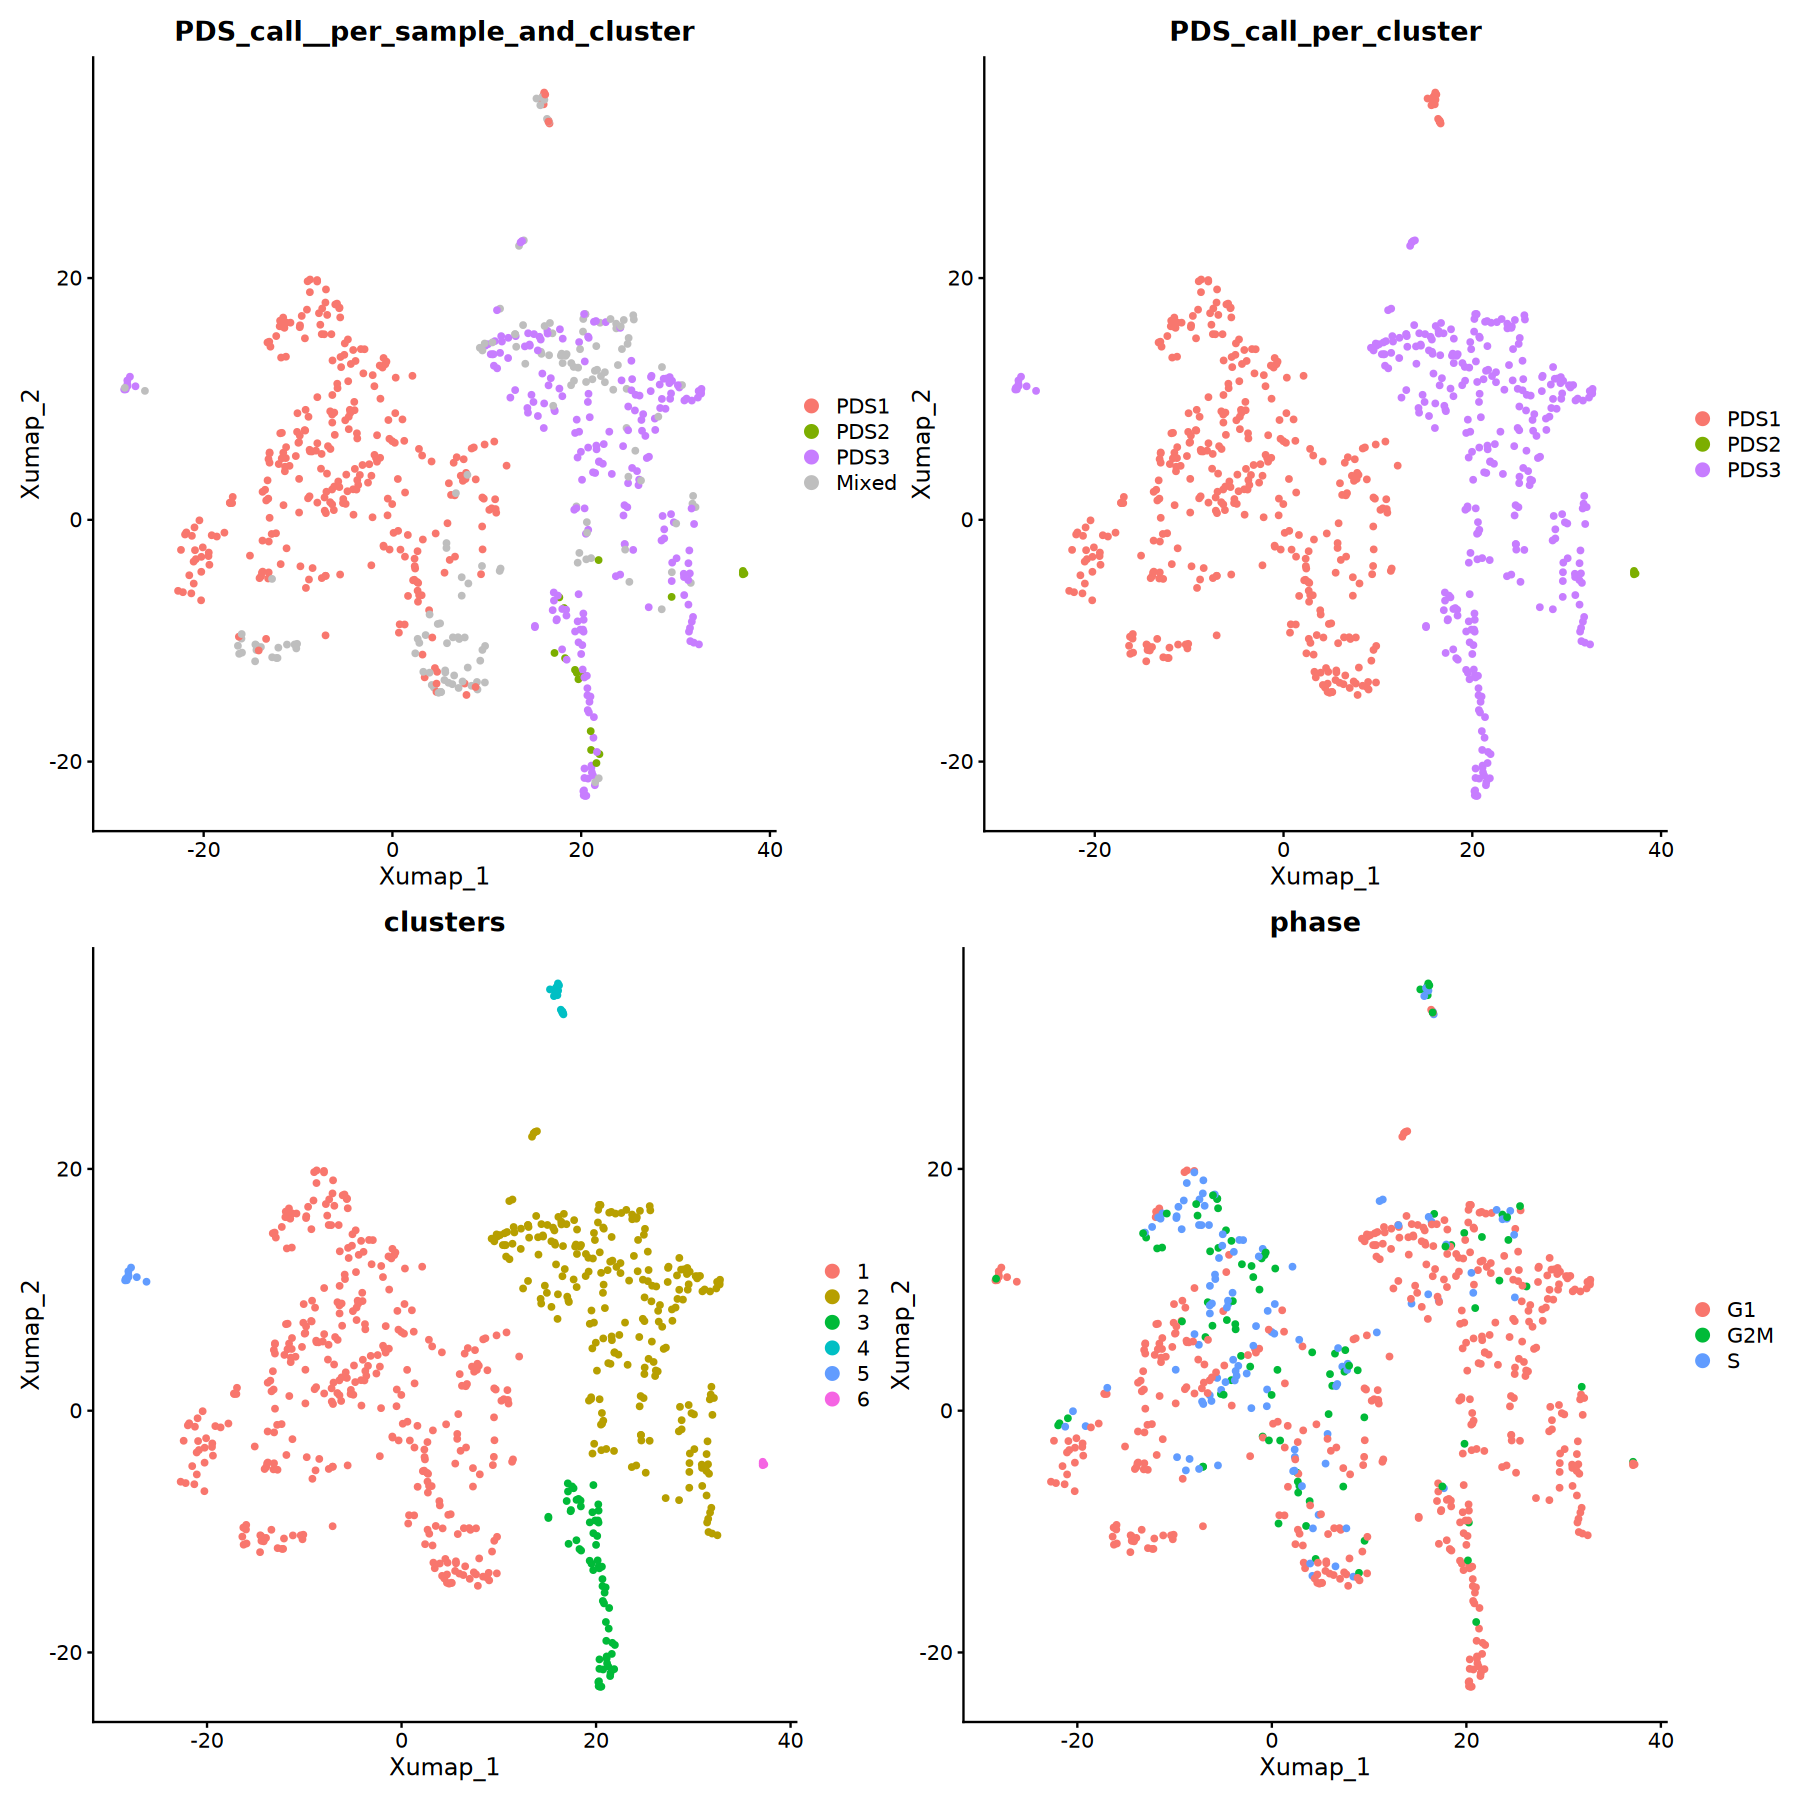

In [21]:
srt$PDS_call__per_sample_and_cluster = PDS.predict_per_sample_and_cluster$PDS_call[match(paste0(gsub("_", "-", gsub("_", "-", srt$sample)), '_', srt$clusters), PDS.predict_per_sample_and_cluster$Sample_ID)]

options(repr.plot.width = 17, repr.plot.height = 11)
DimPlot(srt, group.by = "PDS_call__per_sample_and_cluster", reduction = "umap", split.by = "sample", 
        ncol = 5, cols = pds_col, na.value="lightgrey")

options(repr.plot.width = 15, repr.plot.height = 15)
p4 = DimPlot(srt, group.by = "PDS_call__per_sample_and_cluster", reduction = "umap", 
             cols = pds_col, na.value="lightgrey")
(p4 + p1) / (p2 + p3)

In [22]:
# add a column to the metadata with the number of cells per cluster and sample
srt$cells_per_cluster = as.numeric(table(paste0(srt$sample, '_', srt$clusters))[
    match(paste0(srt$sample, '_', srt$clusters), 
    names(table(paste0(srt$sample, '_', srt$clusters))))
    ])

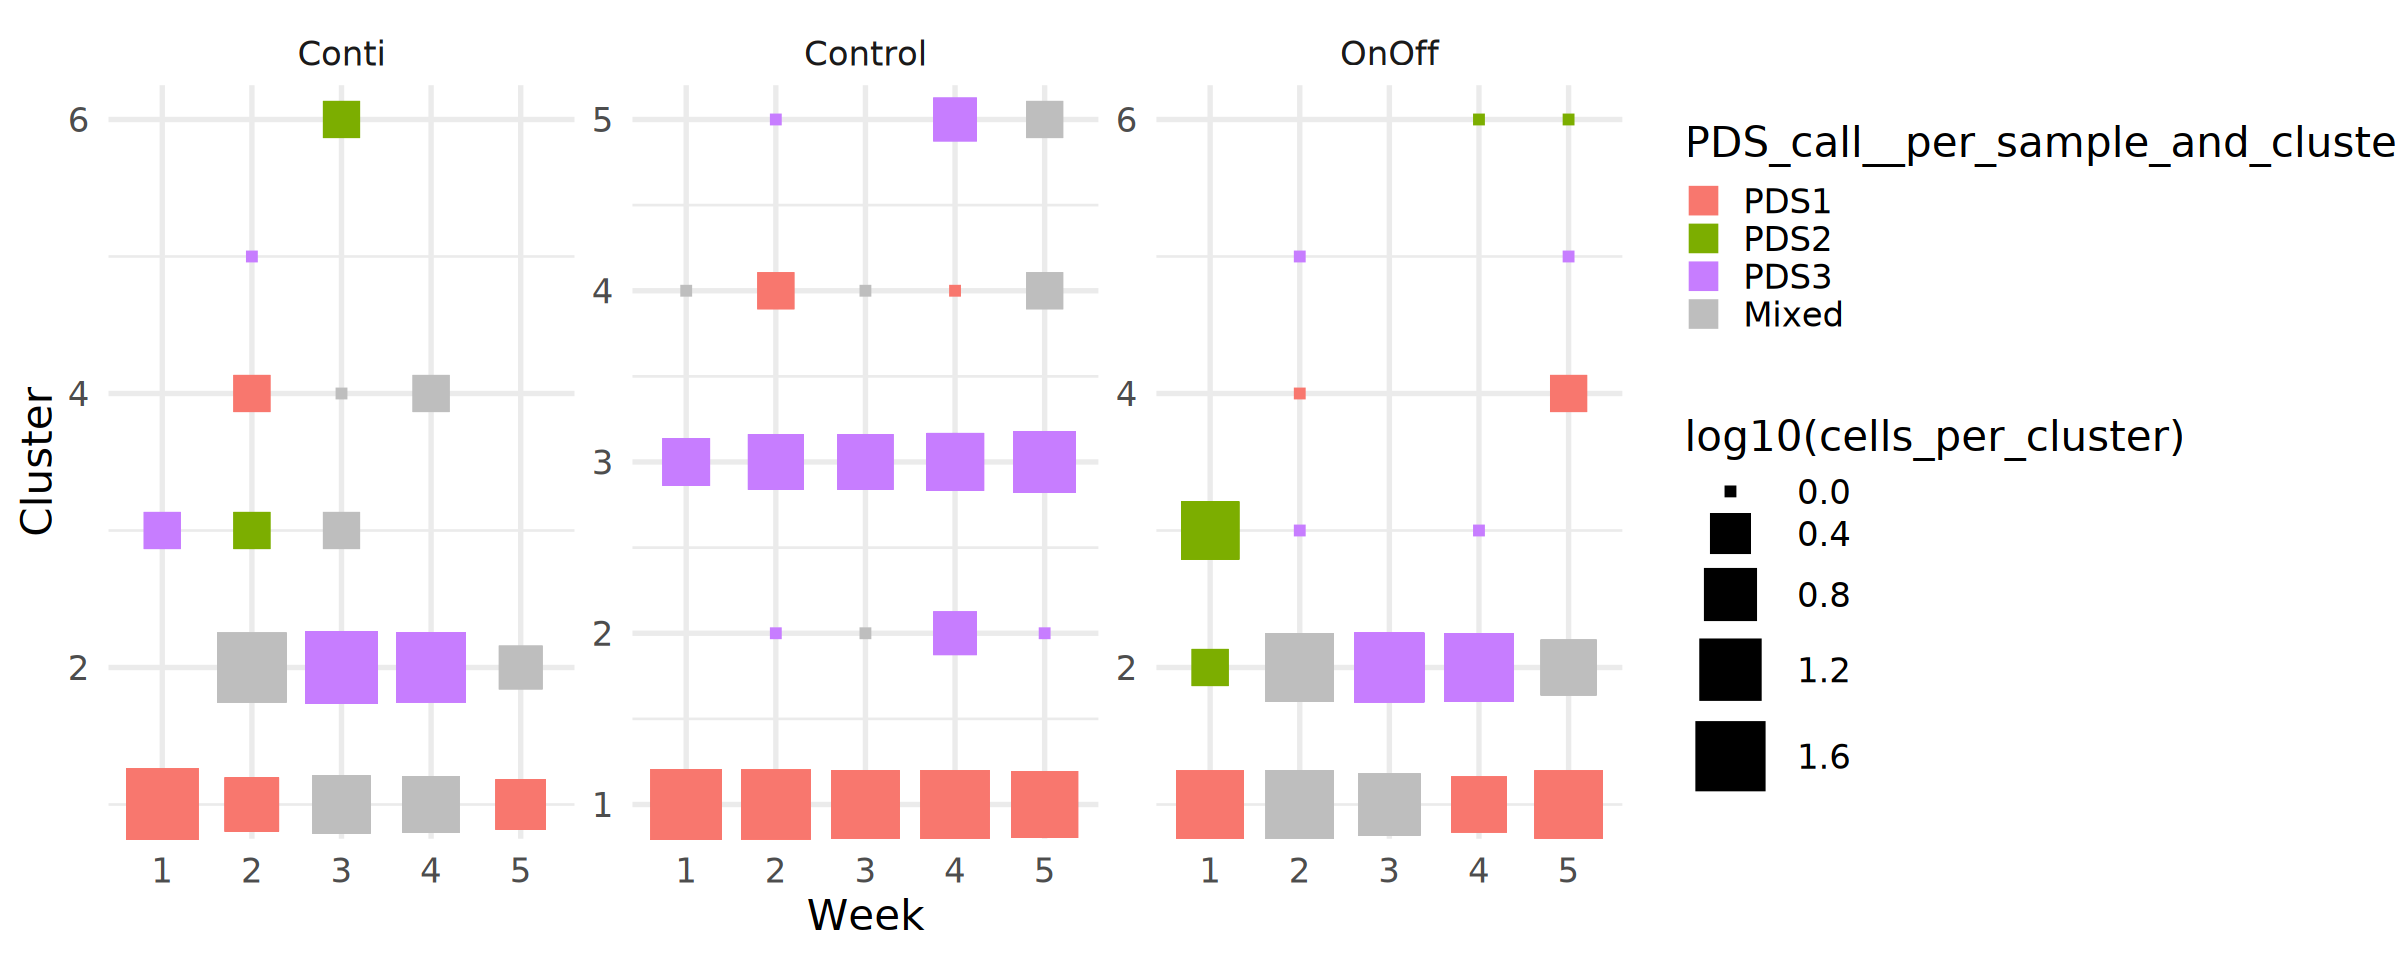

In [23]:
# plot with PDS type per cluster and sample and the size of rectangles proportional to the number of cells in the cluster
options(repr.plot.width = 20, repr.plot.height = 8)
srt@meta.data %>%
    ggplot(aes(x = week, y = clusters, color = PDS_call__per_sample_and_cluster, size = log10(cells_per_cluster))) +
    geom_point(shape = 15) +
    scale_size_continuous(range = c(3, 20)) +
    scale_color_manual(values = pds_col, na.value="lightgrey", guide = guide_legend(override.aes = list(size = 8))) +
    theme_minimal(base_size = 25) +
    labs(x = "Week", y = "Cluster", fill = "PDS type") +
    facet_wrap(~treatment, scales = "free_y")

In [24]:
library(tidyverse)
options(repr.plot.width = 20, repr.plot.height = 10)
PDS.predict_per_sample_and_cluster %>%
    mutate(week = str_remove(Sample_ID, ".*-") %>% str_remove("_.*"),
           treatment = str_remove(Sample_ID, "-.*"),
           cluster = str_remove(Sample_ID, ".*_"),
           treatment_cluster = paste0(treatment, "_", cluster)) %>%
    ggplot(aes(x = week, y = cluster, fill = PDS_call)) +
        geom_rect() +
        scale_fill_manual(values = pds_col, na.value="lightgrey") +
        labs(title = "PDS type per sample and cluster", x = "week", y = "treatment") +
        theme_minimal(base_size = 25) +
        facet_wrap(~treatment)

ERROR while rich displaying an object: Error in `geom_rect()`:
! Problem while setting up geom.
ℹ Error occurred in the 1st layer.
Caused by error in `compute_geom_1()`:
! `geom_rect()` requires the following missing aesthetics: xmin, xmax,
  ymin, and ymax.

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2r

## Pseudobulk per sample

What is the majority of PDS type when looking at samples in their entirety, just as we would see if it was a true bulk sample?

In [25]:
aex_per_sample = AverageExpression(srt, layer = "data", assays = "RNA", 
                                   return.seurat = F, group.by = c("sample"))
aex_per_sample = as.data.frame(aex_per_sample$RNA)

# rownames to first column
aex_per_sample$Gene.Symbol = rownames(aex_per_sample)
aex_per_sample = aex_per_sample[,c(ncol(aex_per_sample), 1:(ncol(aex_per_sample)-1))]
rownames(aex_per_sample) = NULL
head(aex_per_sample)

,Gene.Symbol,C-1,C-2,C-3,C-4,C-5,Conti-1,Conti-2,Conti-3,Conti-4,Conti-5,OnOff-1,OnOff-2,OnOff-3,OnOff-4,OnOff-5
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,NOC2L,0.76181039,0.71507799,0.70556836,0.65635278,0.61191547,0.77054962,0.57454713,0.45975371,0.51261166,0.61254002,0.64408051,0.53136732,0.36602741,0.50229296,0.67225129
2,KLHL17,0.02562043,0.02969794,0.02524779,0.03172049,0.04974995,0.02445192,0.02997236,0.01970818,0.04226777,0.03031469,0.03318032,0.01981000,0.02152594,0.03796199,0.04487364
3,PLEKHN1,0.04812044,0.05616614,0.05754918,0.06398691,0.08920487,0.05768320,0.08693678,0.07083363,0.08653495,0.07657756,0.04677422,0.07242608,0.07327421,0.09833578,0.05752733
4,HES4,0.01767727,0.04451051,0.05143372,0.09724566,0.06581245,0.02701800,0.05807966,0.04265219,0.06287488,0.05522730,0.02301409,0.02388797,0.04011099,0.07628341,0.07445555
5,ISG15,0.56601119,0.79333993,0.58623853,0.62143182,0.62957094,0.71251370,0.82068152,1.02626927,1.11503788,0.90600509,0.55562573,0.92834222,0.94784991,0.70475680,0.55782122
6,AGRN,1.66494236,1.67017204,1.68073081,2.00485571,1.91525184,1.80194307,1.69579839,1.48631729,1.75654003,1.25757240,1.92317616,1.54208312,1.66379785,1.96026202,1.52732975


In [26]:
PDS.predict_per_sample = PDSpredict_fixed(aex_per_sample, species = "human", threshold = 0.6)
PDS.predict_per_sample

Calculating ssGSEA scores...

! Some gene sets have size one. Consider setting minSize > 1



ssGSEA Complete!


Batch Correction (with training set as reference batch)...



Batch Correction Complete!


Applying the svmRBF classification model...



Classification Complete!


,Sample_ID,PDS1,PDS2,PDS3,prediction,PDS_call
,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
C-1,C-1,0.928299719,0.05366009,0.01804019,PDS1,PDS1
C-2,C-2,0.911951820,0.02999528,0.05805290,PDS1,PDS1
C-3,C-3,0.862650217,0.05198865,0.08536113,PDS1,PDS1
C-4,C-4,0.459164662,0.16692938,0.37390596,PDS1,Mixed
C-5,C-5,0.078601725,0.10433224,0.81706604,PDS3,PDS3
Conti-1,Conti-1,0.947399446,0.04091429,0.01168627,PDS1,PDS1
Conti-2,Conti-2,0.067403479,0.44249798,0.49009854,PDS3,Mixed
Conti-3,Conti-3,0.004275558,0.70476598,0.29095846,PDS2,PDS2
Conti-4,Conti-4,0.009940756,0.45441926,0.53563999,PDS3,Mixed


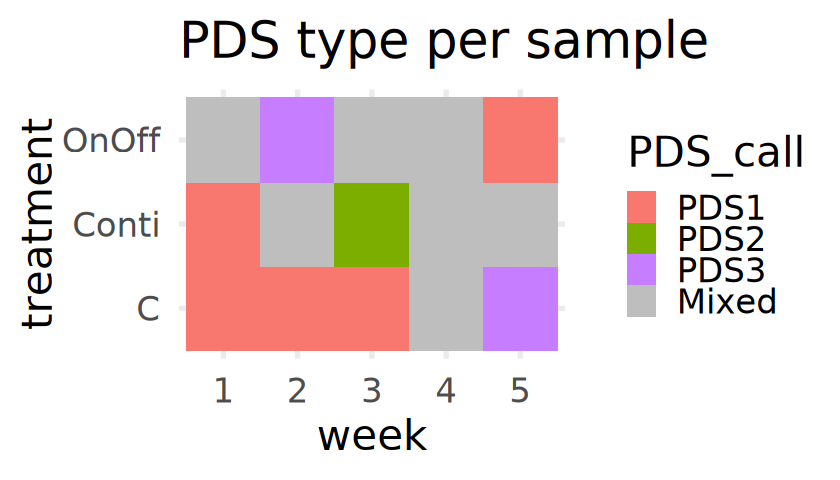

In [27]:
library(tidyverse)
options(repr.plot.width = 7, repr.plot.height = 4)
PDS.predict_per_sample %>%
    mutate(week = str_remove(Sample_ID, ".*-"),
           treatment = str_remove(Sample_ID, "-.*")) %>%
    ggplot(aes(x = week, y = treatment, fill = PDS_call)) +
        geom_tile() +
        scale_fill_manual(values = pds_col, na.value="lightgrey") +
        labs(title = "PDS type per sample", x = "week", y = "treatment") +
        theme_minimal(base_size = 25)

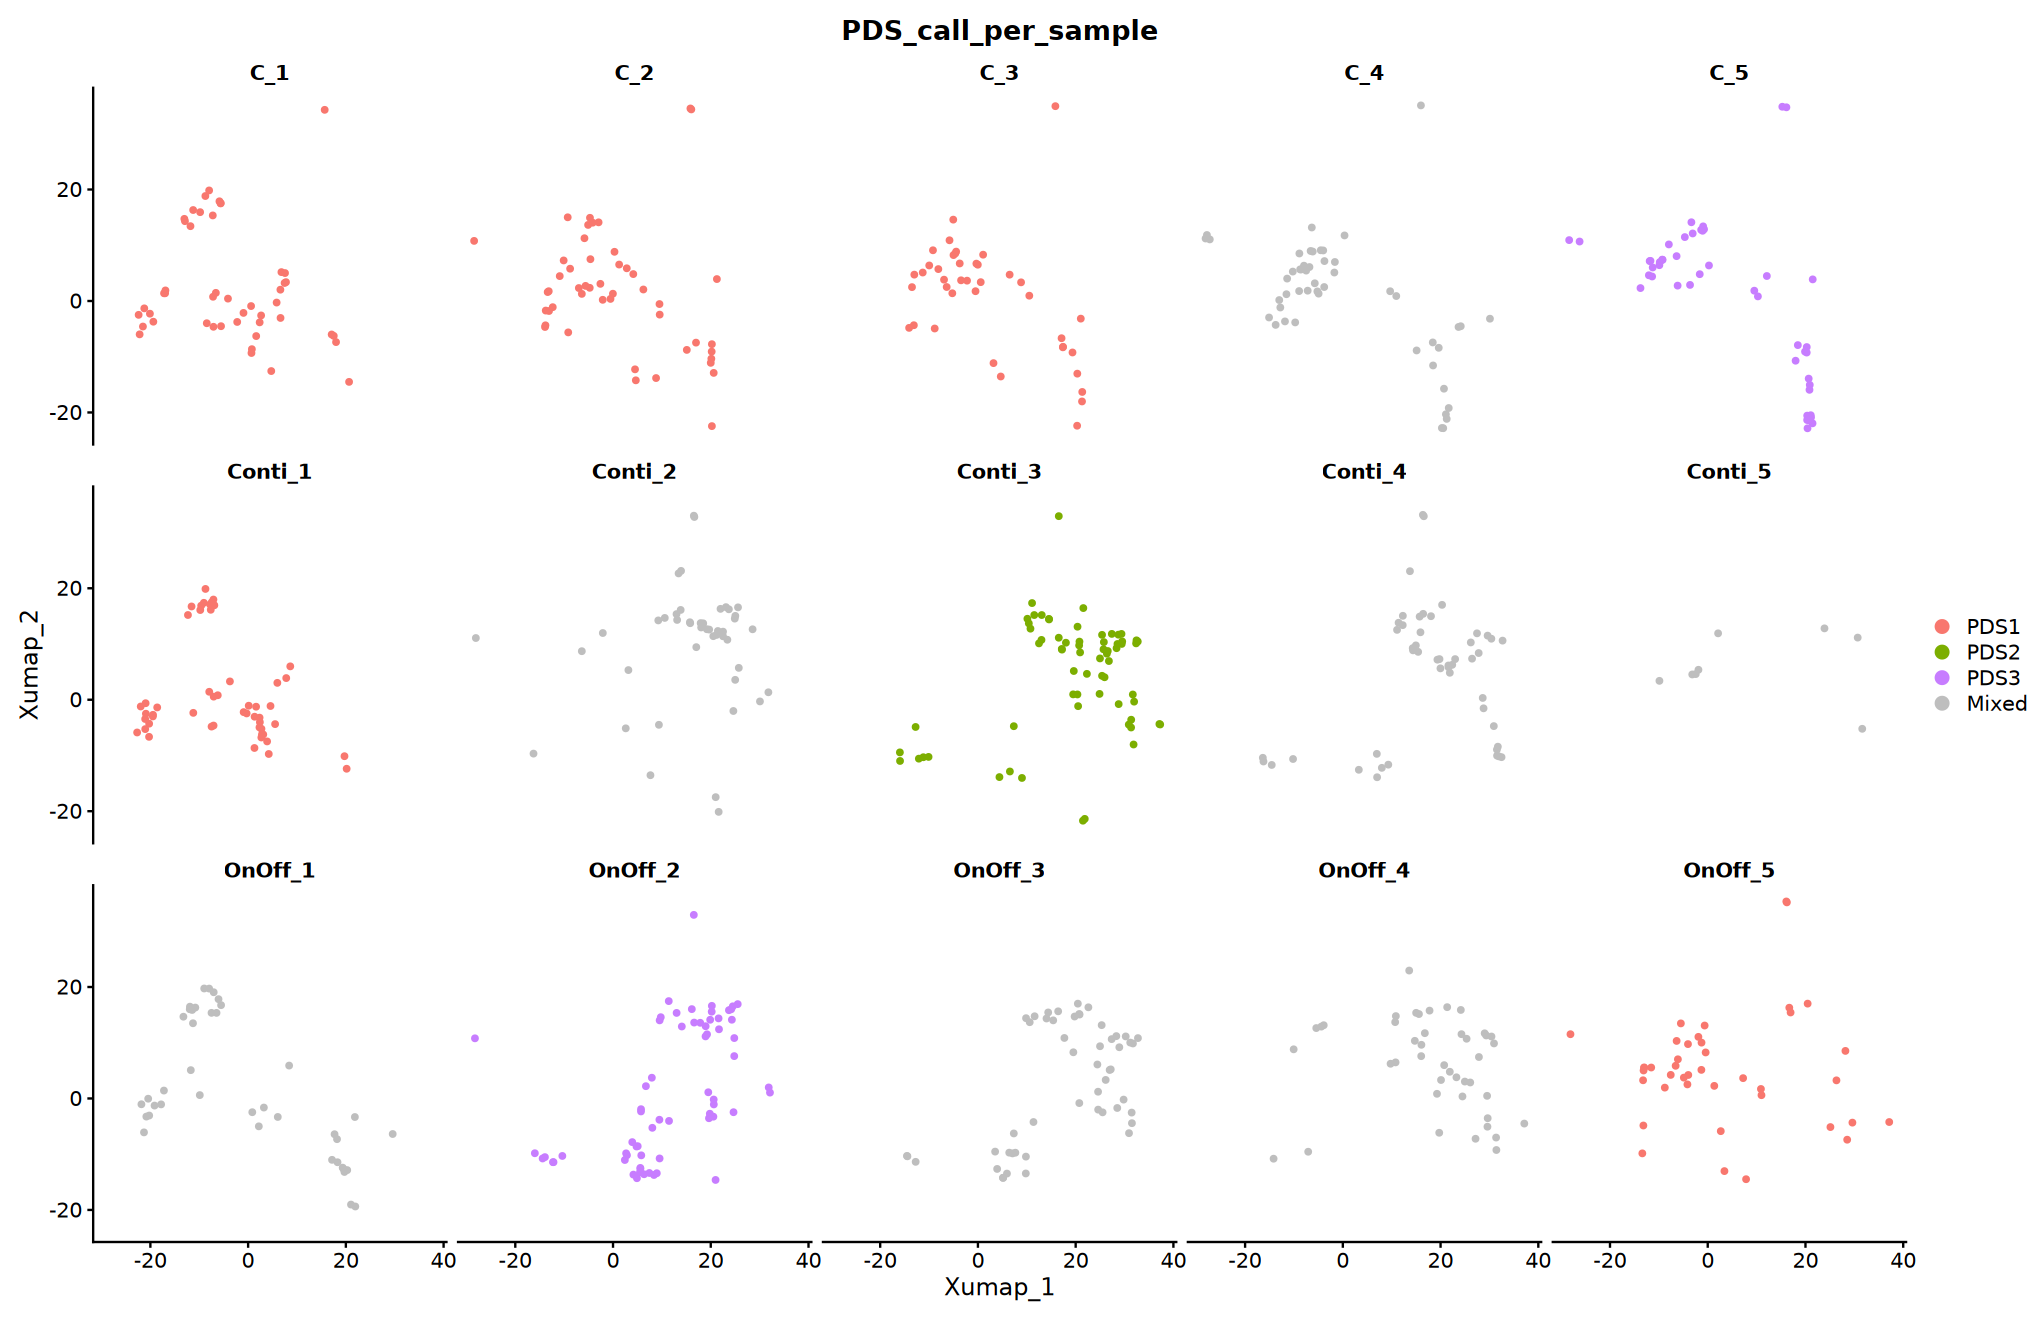

In [28]:
# add to seurat object, associate sample with pds call
srt$PDS_call_per_sample = PDS.predict_per_sample$PDS_call[match(gsub("_", "-", gsub("_", "-", srt$sample)), PDS.predict_per_sample$Sample_ID)]
options(repr.plot.width = 17, repr.plot.height = 11)
DimPlot(srt, group.by = "PDS_call_per_sample", reduction = "umap", split.by = "sample", 
        ncol = 5, cols = pds_col, na.value="lightgrey")

# Stem Maturation Index (SMI)

> calculateSMI() function enable users to determine if the given sample (bulk tissue or single-cell) is transcriptionally stem-like or differentiated-like with Stem Maturation Index (SMI). The outcome provides single sample gene set enrichment analysis (ssGSEA) score for MYC targets and PRC targets, and from these, SMI is calculate (provided unscaled and scaled (-1 to 1)).

Figure 5n and 5j from their paper:

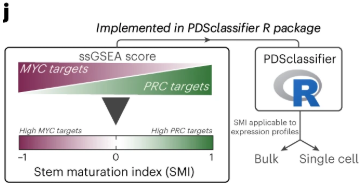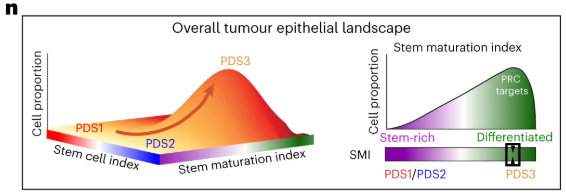

>Given the absence of stem populations in PDS3 and an association of MYC–PRC with stem–differentiation, we proposed a PDS-related stem–differentiation single sample scoring system for use in bulk and single-cell data, termed the ‘stem maturation index’ (SMI; Fig. 5j). Evaluation of the SMI in single-cell and bulk tissue datasets confirmed a clear correlation with PRC targets scores, differentiated colonic cells and PDS3 tumors (Fig. 5k,l and Extended Data Fig. 5i,j). Additionally, expression levels of several differentiation marker genes were also elevated in PDS3 and positively correlated with the SMI, further confirming PDS association along the phenotypic landscape of stem-to-differentiation, with PDS3 tumors having reduced stem populations and an increased abundance of epithelial cells that are further along the differentiated trajectory (Fig. 5m, Extended Data Figs. 5k,l and 6a,b).

>### Calculation of the SMI
>The SMI provides a method of transcriptomic measure along the stem–differentiation continuum in association with stem-like or differentiation-like properties. SMI can be calculated from the gene expression profile of both bulk tumor tissue and single-cell data and is simply the difference between the PRC targets and MYC targets ssGSEA score scaled between a value of −1 and 1. The method has also been implemented in the PDSclassifier R package in the form of the calculateSMI function.

As single cell data.

In [ ]:
# library(escape)

In [ ]:
# escape.matrix <- function(input.data, 
#                           gene.sets = NULL, 
#                           method = "ssGSEA", 
#                           groups = 1000, 
#                           min.size = 5,
#                           normalize = FALSE,
#                           make.positive = FALSE,
#                           BPPARAM = SerialParam(),
#                           ...) {
#     egc <- .GS.check(gene.sets)
#     cnts <- .cntEval(input.data, assay = "RNA", type = "counts")
#     egc.size <- lapply(egc, function(x) length(which(rownames(cnts) %in% x)))
#     if (!is.null(min.size)){
#       remove <- unname(which(egc.size < min.size))
#       if(length(remove) > 0) {
#         egc <- egc[-remove]
#         egc.size <- egc.size[-remove]
#         if(length(egc) == 0) {
#           stop("No gene sets passed the minimum length - please reconsider the 'min.size' parameter")
#         }
#       }
#     }
    
#     scores <- list()
#     splits <- seq(1, ncol(cnts), by=groups)
#     print(paste('Using sets of', groups, 'cells. Running', 
#                 length(splits), 'times.'))
#     split.data <- .split_data.matrix(matrix=cnts, chunk.size=groups)
    
#     all_gene_sets <- names(egc) # Collect all gene set names
    
#     for (i in seq_along(splits)) {
#       if (method == "GSVA") {
#         parameters <- .gsva.setup(split.data[[i]], egc)
#       } else if (method == "ssGSEA") {
#         parameters <- .ssGSEA.setup(split.data[[i]], egc)
#       }
#       if (method %in% c("ssGSEA", "GSVA")) {
#         a <- suppressWarnings(gsva(param = parameters, 
#                                    verbose = FALSE,
#                                    BPPARAM = BPPARAM,
#                                    ...))
#       } else if (method == "UCell") {
#         a <- t(suppressWarnings(
#           ScoreSignatures_UCell(matrix = split.data[[i]], 
#                                 features = egc,
#                                 name = NULL,
#                                 BPPARAM = BPPARAM,
#                                 ...)))
#       } else if (method == "AUCell") {
#         rankings <- AUCell_buildRankings(split.data[[i]],
#                                          plotStats = FALSE,
#                                          verbose = FALSE)
#         a <- assay(AUCell_calcAUC(geneSets = egc,
#                                   rankings,
#                                   normAUC = TRUE,
#                                   aucMaxRank = ceiling(0.2 * nrow(split.data[[i]])),
#                                   verbose = FALSE,
#                                   ...))
#       }
      
#       # Ensure consistent row names (all_gene_sets) across splits
#       a <- as.data.frame(a)
#       a <- a[match(all_gene_sets, rownames(a), nomatch = NA), , drop = FALSE]
#       scores[[i]] <- a
#     }
#     scores <- do.call(cbind, scores)
#     output <- t(as.matrix(scores))
    
#     #Normalize based on dropout
#     if(normalize) {
#       output <- performNormalization(sc.data = input.data,
#                                      enrichment.data = output,
#                                      assay = NULL,
#                                      gene.sets = gene.sets,
#                                      make.positive = make.positive,
#                                      groups = groups)
#     }
#     return(output)
# }

# .GS.check <- function(gene.sets) {
#   if(is.null(gene.sets)) {
#     stop("Please provide the gene.sets you would like to use for 
#             the enrichment analysis")
#   }
#   egc <- gene.sets
#   if(inherits(egc, what = "GeneSetCollection")){
#     egc <- GSEABase::geneIds(egc) # will return a simple list, 
#     #which will work if a matrix is supplied to GSVA
#   }
#   return(egc)
# }


# ## The function below was taked from escape R package
# cntEval <- function (obj)
# {
#   if (inherits(x = obj, what = "Seurat")) {
#     cnts <- Seurat::GetAssayData(obj)
#   }
#   else if (inherits(x = obj, what = "SingleCellExperiment")) {
#     cnts <- SingleCellExperiment::counts(obj)
#   }
#   else {
#     cnts <- obj
#   }
#   if (!inherits(cnts, what = "dgCMatrix")) {
#     cnts <- Matrix::Matrix(as.matrix(cnts), sparse = TRUE)
#   }
#   return(cnts)
# }

In [ ]:
# data = srt
# datatype = "sc"
# species = "human"
# library(matrixStats)

# ### Select only human geneset by default ----
# geneset <- myc_prc_gs_list[names(myc_prc_gs_list)[grep("_Human", names(myc_prc_gs_list))]]
# names(geneset) <- gsub("_Human", "_Targets", names(geneset))

# ## to check, the number of genes matching, we will extract matrix from the single-cell data
# ## using function from escape:::cntEval
# cnts <- escape:::cntEval(data)
# ### Check the proportion of genes in each geneset which are present in the expression data
# genes_matched_prop <- lapply(geneset,
#                               function(genes) sum(genes %in% rownames(cnts)) / length(genes))

# ## if less than 5 genes, stop or else calculate scores
# if(all((genes_matched_prop < 0.05) == TRUE)) {
#   stop("Less than 5 genes (minimum) from the genesets were found in the data.")
# }

# utils::packageVersion("escape")

# ## run escape to calculate scores ----
# myc_prc_score <- escape::enrichIt(obj = data,
#                                   gene.sets = geneset, method = 'ssGSEA',
#                                   groups = 10000, cores = 4,
#                                   min.size = 5)

[1] ‘2.2.3’

ERROR: Error in as.data.frame.default(data): cannot coerce class ‘structure("Seurat", package = "SeuratObject")’ to a data.frame


In [ ]:
# ## into dataframe ----
# myc_prc_score_copy <- as.data.frame(myc_prc_score)

# ## Calculate SMI (unscaled) ----
# myc_prc_score_copy[["SMI_unscaled"]] <- myc_prc_score_copy[,1]-myc_prc_score_copy[,2] ## PRC - MYC
# ## Scale SMI between -1 to 1 ----
# myc_prc_score_copy[["SMI"]] <- scales::rescale(myc_prc_score_copy[["SMI_unscaled"]], to = c(-1, 1))
# myc_prc_score_copy |> head()

In [ ]:
# all(colnames(srt[['RNA']]$counts) == rownames(myc_prc_score_copy))

In [ ]:
# # add results to seurat object
# srt$PCR_Targets = myc_prc_score_copy$PRC_Targets
# srt$MYC_Targets = myc_prc_score_copy$MYC_Targets
# srt$SMI_unscaled_per_cell = myc_prc_score_copy$SMI_unscaled
# srt$SMI_per_cell = myc_prc_score_copy$SMI

In [ ]:
# library(scCustomize)
# library(patchwork)
# p5 = FeaturePlot_scCustom(srt, features = "SMI_per_cell", aspect_ratio=1, reduction = "umap", na_cutoff = NA)
# options(repr.plot.width = 15, repr.plot.height = 15)
# p5 + p1 + p2 + p3 + plot_layout(ncol = 2)

scCustomize v3.0.1
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



ERROR: [1m[33mError[39m in `Feature_PreCheck()`:[22m
[1m[22m[33m![39m No features were found.
[36m•[39m The following are not present in object:
[36mℹ[39m [32mSMI_per_cell[39m


In [ ]:
# srt$sample = factor(srt$sample, levels = c(paste0("C_", 1:5), paste0("OnOff_", 1:5), paste0("Conti_", 1:5)))
# options(repr.plot.width = 17, repr.plot.height = 11)
# FeaturePlot_scCustom(srt, features = "SMI_per_cell", num_columns = 5, split.by = "sample", aspect_ratio=1, reduction = "umap", na_cutoff = NA)